# [EXPLORATION] Netztransparenz API - Activated Balancing Volumes

## Header & Resources

- **Official API Portal:** https://ds.netztransparenz.de/api/v1/data  
- **API Documentation / Auth:** https://identity.netztransparenz.de/users/connect/token  
- **Key Endpoint Parameters:**
  - `series` (e.g., `AktivierteSRL`, `AktivierteMRL`, `NRVSaldo`, `RZSaldo`, `reBAP`)
  - `quality` (e.g., `Qualitaetsgesichert`, `Betrieblich`)
  - `start`, `end` (ISO8601 window, requested in UTC format)

This notebook is structured as a scientific validation document for raw API behavior, data quality, and timezone integrity before ingestion.

## Scientific Notation & Mapping Table

| Original API Column | Thesis Notation (LaTeX) | Unit | Description |
|---|---|---|---|
| AktivierteSRL Positiv | $P^{+}_{aFRR,t}$ | MW | Activated positive aFRR power at time $t$. |
| AktivierteSRL Negativ | $P^{-}_{aFRR,t}$ | MW | Activated negative aFRR power at time $t$. |
| AktivierteMRL Positiv | $P^{+}_{mFRR,t}$ | MW | Activated positive mFRR power at time $t$. |
| AktivierteMRL Negativ | $P^{-}_{mFRR,t}$ | MW | Activated negative mFRR power at time $t$. |
| NRVSaldo | $NRV_t$ | MW | Net regulation volume balance at time $t$. |
| RZSaldo | $RZ_t$ | MW | Control zone saldo at time $t$. |
| reBAP | $P_{reBAP,t}$ | EUR/MWh | Balancing energy settlement price at time $t$. |
| Activated Energy (derived) | $\Delta E_{act,t}$ | MWh | Derived energy from power and resolution, e.g. $\Delta E_{act,t}=P_{act,t}\cdot\Delta t$. |


## Implementation

In [36]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime, timedelta, timezone
import io
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
from IPython.display import display

for candidate in (Path.cwd() / '.env', Path.cwd().parent / '.env', Path.cwd().parents[1] / '.env'):
    if candidate.exists():
        load_dotenv(candidate)

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'api' else Path.cwd().resolve()
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from energy_trading.visualization.style import apply_geo_style

apply_geo_style()


In [37]:
def _ensure_bearer(token: str) -> str:
    return token if token.startswith('Bearer ') else f'Bearer {token}'


def _fetch_token_from_client_credentials(client_id: str, client_secret: str) -> str:
    # Keep this identical to fetch_netztransparenz.py to avoid auth drift.
    token_url = 'https://identity.netztransparenz.de/users/connect/token'
    payload = {
        'grant_type': 'client_credentials',
        'client_id': client_id,
        'client_secret': client_secret,
    }
    headers = {'Content-Type': 'application/x-www-form-urlencoded'}

    resp = requests.post(token_url, headers=headers, data=payload, timeout=60)
    try:
        resp.raise_for_status()
    except requests.HTTPError as exc:
        detail = resp.text[:500] if resp.text else 'no response body'
        raise RuntimeError(f'Token request failed ({resp.status_code}): {detail}') from exc

    token = resp.json().get('access_token')
    if not token:
        raise RuntimeError('Token response missing access_token')
    return _ensure_bearer(token)


def get_token() -> str:
    # 1) direct bearer token if provided
    token = os.getenv('NETZTRANSPARENZ_TOKEN')
    if token:
        return _ensure_bearer(token)

    # 2) fallback to client-credentials flow
    client_id = os.getenv('NETZTRANSPARENZ_CLIENT_ID')
    client_secret = os.getenv('NETZTRANSPARENZ_CLIENT_SECRET')
    if client_id and client_secret:
        return _fetch_token_from_client_credentials(client_id, client_secret)

    raise RuntimeError(
        'No credentials found. Set NETZTRANSPARENZ_TOKEN or '
        'NETZTRANSPARENZ_CLIENT_ID/NETZTRANSPARENZ_CLIENT_SECRET.'
    )



def _fmt_utc(dt: datetime) -> str:
    return dt.astimezone(timezone.utc).strftime('%Y-%m-%dT%H:%MZ')


def fetch_netztransparenz_csv(
    series: str,
    quality: str,
    start_utc: datetime,
    end_utc: datetime,
    token: str,
    timeout: int = 60,
) -> pd.DataFrame:
    """Fetch one Netztransparenz CSV endpoint with defensive error handling."""
    base_url = 'https://ds.netztransparenz.de/api/v1/data'
    url = f"{base_url}/NrvSaldo/{series}/{quality}/{_fmt_utc(start_utc)}/{_fmt_utc(end_utc)}"
    headers = {'Authorization': _ensure_bearer(token), 'Accept': 'text/csv'}

    try:
        resp = requests.get(url, headers=headers, timeout=timeout)
        resp.raise_for_status()
    except requests.RequestException as exc:
        detail = ''
        if 'resp' in locals() and getattr(resp, 'text', None):
            detail = resp.text[:500]
        raise RuntimeError(f'Netztransparenz request failed for {series} ({quality}): {exc}. {detail}') from exc

    try:
        df = pd.read_csv(io.StringIO(resp.text), sep=';', decimal=',', low_memory=False)
    except Exception as exc:
        raise RuntimeError(f'CSV parsing failed for {series}: {exc}') from exc

    df.columns = [str(c).strip() for c in df.columns]
    return df


In [38]:
# Fetch all relevant endpoints used by fetch_netztransparenz.py
# Window can be changed for debugging/comparison.
START_UTC = datetime(2025, 8, 1, 10, 0, tzinfo=timezone.utc)
END_UTC = START_UTC + timedelta(days=7)

TOKEN = get_token()


def _parse_timestamp_utc(df: pd.DataFrame) -> pd.Series:
    """Parse Datum+von as UTC timestamps."""
    date_col = next((c for c in df.columns if c.lower() == 'datum'), None)
    time_col = next((c for c in df.columns if c.lower() in {'von', 'time'}), None)
    if not date_col or not time_col:
        return pd.Series(pd.NaT, index=df.index, dtype='datetime64[ns, UTC]')

    ts = pd.to_datetime(
        df[date_col].astype(str) + ' ' + df[time_col].astype(str),
        format='%d.%m.%Y %H:%M',
        errors='coerce',
    )
    return ts.dt.tz_localize('UTC')


def _find_value_col(df: pd.DataFrame, exclude: set[str] | None = None) -> str:
    exclude = exclude or set()
    low_ex = {e.lower() for e in exclude}
    for c in df.columns[::-1]:
        cl = c.lower()
        if cl in {'datum', 'von', 'time', 'zeitzone', 'bis', 'einheit'} or cl in low_ex:
            continue
        return c
    raise RuntimeError('No value column detected')


def _parse_german_mw_series(s: pd.Series) -> pd.Series:
    """Robust parser for mixed German number formats in MW columns."""
    txt = s.astype(str).str.strip()
    both = txt.str.contains('.', regex=False) & txt.str.contains(',', regex=False)
    comma_only = (~both) & txt.str.contains(',', regex=False)

    out = txt.copy()
    out.loc[both] = out.loc[both].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    out.loc[comma_only] = out.loc[comma_only].str.replace(',', '.', regex=False)
    out = out.replace({'': pd.NA, 'nan': pd.NA, 'N.A.': pd.NA, 'N/A': pd.NA})
    return pd.to_numeric(out, errors='coerce')


# --- Explicit API mapping for canonical Netztransparenz columns used in the pipeline ---
# Required canonical columns:
#   NRV_balance_qs, NRV_balance_op, NRV_balance,
#   reBAP_shortage_surplus,
#   rz_saldo_mw_qs, rz_saldo_mw_op, rz_saldo_mw
API_SERIES_MAP = {
    'NRV_balance_qs': ('NRVSaldo', 'Qualitaetsgesichert'),
    'NRV_balance_op': ('NRVSaldo', 'Betrieblich'),
    'reBAP_shortage_surplus': ('reBAP', 'Qualitaetsgesichert'),
    'rz_saldo_mw_qs': ('RZSaldo', 'Qualitaetsgesichert'),
    'rz_saldo_mw_op': ('RZSaldo', 'Betrieblich'),
    # Activation series kept for full schema comparison.
    'afrr_activated': ('AktivierteSRL', 'Qualitaetsgesichert'),
    'mfrr_activated': ('AktivierteMRL', 'Qualitaetsgesichert'),
}

raw_payloads: dict[str, pd.DataFrame] = {}
for out_col, (series, quality) in API_SERIES_MAP.items():
    raw_payloads[out_col] = fetch_netztransparenz_csv(series, quality, START_UTC, END_UTC, TOKEN)

print('Raw payload sizes:')
for k, v in raw_payloads.items():
    print(f'  {k:<24} {v.shape}')

# Keep one raw reference for existing inspection cells
df_raw = raw_payloads['afrr_activated'].copy()
print('First 5 rows (raw AktivierteSRL QS):')
display(df_raw.head(5))


def _single_series(df: pd.DataFrame, out_col: str) -> pd.DataFrame:
    ts = _parse_timestamp_utc(df)
    val_col = _find_value_col(df)
    val = _parse_german_mw_series(df[val_col])
    return pd.DataFrame({'timestamp_utc': ts, out_col: val}).dropna(subset=['timestamp_utc'])


def _rz_saldo_series(df: pd.DataFrame, out_col: str) -> pd.DataFrame:
    """Parse and aggregate RZ-Saldo from 4 TSO columns to one 15-min MW series."""
    ts = _parse_timestamp_utc(df)
    tso_cols = ['50Hertz', 'Amprion', 'TenneT TSO', 'TransnetBW']
    missing = [c for c in tso_cols if c not in df.columns]
    if missing:
        raise RuntimeError(f'Missing expected RZ TSO columns: {missing}')

    vals = {c: _parse_german_mw_series(df[c]).astype('float64') for c in tso_cols}
    agg = pd.DataFrame(vals).sum(axis=1, min_count=1)

    # Sanity check: catch parsing explosions from locale issues.
    vmax = float(agg.max(skipna=True))
    vmin = float(agg.min(skipna=True))
    print(f'{out_col} min/max: {vmin:.3f} / {vmax:.3f}')
    if vmax > 10_000 or vmin < -10_000:
        raise RuntimeError(
            f'{out_col} out of physical bounds (+/-10,000 MW). Check number parsing.'
        )

    return pd.DataFrame({'timestamp_utc': ts, out_col: agg}).dropna(subset=['timestamp_utc'])


def _activation_series(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    ts = _parse_timestamp_utc(df)
    pos_cols = [c for c in df.columns if 'positiv' in c.lower()]
    neg_cols = [c for c in df.columns if 'negativ' in c.lower()]
    if not pos_cols or not neg_cols:
        raise RuntimeError(f'Missing pos/neg columns in {prefix}')

    # Prefer Deutschland totals when available; else sum all component columns.
    pos_de = [c for c in pos_cols if 'deutschland' in c.lower()]
    neg_de = [c for c in neg_cols if 'deutschland' in c.lower()]
    use_pos = pos_de if pos_de else pos_cols
    use_neg = neg_de if neg_de else neg_cols

    out = pd.DataFrame({'timestamp_utc': ts})
    out[f'{prefix}_mw_pos'] = pd.concat([_parse_german_mw_series(df[c]) for c in use_pos], axis=1).sum(axis=1, min_count=1)
    out[f'{prefix}_mw_neg'] = pd.concat([_parse_german_mw_series(df[c]) for c in use_neg], axis=1).sum(axis=1, min_count=1)
    return out.dropna(subset=['timestamp_utc'])


nrv_qs = _single_series(raw_payloads['NRV_balance_qs'], 'NRV_balance_qs')
nrv_op = _single_series(raw_payloads['NRV_balance_op'], 'NRV_balance_op')
rz_qs = _rz_saldo_series(raw_payloads['rz_saldo_mw_qs'], 'rz_saldo_mw_qs')
rz_op = _rz_saldo_series(raw_payloads['rz_saldo_mw_op'], 'rz_saldo_mw_op')
rebap = _single_series(raw_payloads['reBAP_shortage_surplus'], 'reBAP_shortage_surplus')
afrr = _activation_series(raw_payloads['afrr_activated'], 'afrr_activated')
mfrr = _activation_series(raw_payloads['mfrr_activated'], 'mfrr_activated')

# Merge and apply fallback (QS first, Betrieblich second) for NRV/RZ
merged = (
    afrr.merge(mfrr, on='timestamp_utc', how='outer')
        .merge(nrv_qs, on='timestamp_utc', how='outer')
        .merge(nrv_op, on='timestamp_utc', how='outer')
        .merge(rz_qs, on='timestamp_utc', how='outer')
        .merge(rz_op, on='timestamp_utc', how='outer')
        .merge(rebap, on='timestamp_utc', how='outer')
)

merged['NRV_balance'] = merged['NRV_balance_qs'].combine_first(merged['NRV_balance_op'])
merged['rz_saldo_mw'] = merged['rz_saldo_mw_qs'].combine_first(merged['rz_saldo_mw_op'])

# Source diagnostics for fallback usage
merged['NRV_source'] = merged['NRV_balance_qs'].notna().map({True: 'qs', False: None})
merged.loc[merged['NRV_source'].isna() & merged['NRV_balance_op'].notna(), 'NRV_source'] = 'betrieblich'
merged['RZ_source'] = merged['rz_saldo_mw_qs'].notna().map({True: 'qs', False: None})
merged.loc[merged['RZ_source'].isna() & merged['rz_saldo_mw_op'].notna(), 'RZ_source'] = 'betrieblich'

merged = merged.sort_values('timestamp_utc').reset_index(drop=True)
df_merged = merged

print('Merged validation frame:', df_merged.shape)
print('Fallback usage summary:')
print('  NRV source counts:', df_merged['NRV_source'].value_counts(dropna=False).to_dict())
print('  RZ source counts :', df_merged['RZ_source'].value_counts(dropna=False).to_dict())

# NOTE: Betrieblich is used as fallback for NRV and RZ only.


Raw payload sizes:
  NRV_balance_qs           (672, 8)
  NRV_balance_op           (672, 11)
  reBAP_shortage_surplus   (672, 9)
  rz_saldo_mw_qs           (672, 11)
  rz_saldo_mw_op           (672, 11)
  afrr_activated           (672, 17)
  mfrr_activated           (672, 17)
First 5 rows (raw AktivierteSRL QS):


,Datum,Zeitzone,von,bis,Datenkategorie,Datentyp,Einheit,50Hertz (Positiv),Amprion (Positiv),TenneT TSO (Positiv),TransnetBW (Positiv),Deutschland (Positiv),50Hertz (Negativ),Amprion (Negativ),TenneT TSO (Negativ),TransnetBW (Negativ),Deutschland (Negativ)
0,01.08.2025,UTC,10:00,10:15,Aktivierte SRL,Qualitätsgesichert,MW,0.0,0.0,0.0,0.0,0.0,81.812,20.732,37.264,45.248,185.056
1,01.08.2025,UTC,10:15,10:30,Aktivierte SRL,Qualitätsgesichert,MW,0.0,0.0,0.0,0.0,0.0,108.376,33.488,36.624,21.460,199.948
2,01.08.2025,UTC,10:30,10:45,Aktivierte SRL,Qualitätsgesichert,MW,0.0,0.0,0.0,0.0,0.0,86.804,35.676,15.316,16.392,154.188
3,01.08.2025,UTC,10:45,11:00,Aktivierte SRL,Qualitätsgesichert,MW,0.0,0.0,0.0,0.0,0.0,87.072,40.040,12.688,6.188,145.988
4,01.08.2025,UTC,11:00,11:15,Aktivierte SRL,Qualitätsgesichert,MW,0.0,0.0,0.0,0.0,0.0,53.340,2.672,1.160,0.276,57.448


rz_saldo_mw_qs min/max: -1581.264 / 1628.952
rz_saldo_mw_op min/max: -1643.560 / 1640.644
Merged validation frame: (672, 14)
Fallback usage summary:
  NRV source counts: {'qs': 672}
  RZ source counts : {'qs': 672}


### RZ-Saldo API validation (UTC 2025-08-01 10:00, 6h)

This check makes the RZ-Saldo transformation fully transparent:
1. Fetch **RZSaldo / Qualitaetsgesichert** directly from the API.
2. Parse and sum the four TSO columns (`50Hertz`, `Amprion`, `TenneT TSO`, `TransnetBW`) per 15-minute row.
3. Aggregate to hourly values by **mean of the four quarter-hours**.
4. Compare with `rz_saldo_mw_qs` from `data/raw/netztransparenz.parquet`.
5. If available, compare against the external CSV file (Column K helper).


In [39]:
# Narrow validation window requested in thesis QA workflow
RZ_START_UTC = datetime(2025, 8, 1, 10, 0, tzinfo=timezone.utc)
RZ_END_UTC = RZ_START_UTC + timedelta(hours=6)

rz_raw = fetch_netztransparenz_csv(
    series='RZSaldo',
    quality='Qualitaetsgesichert',
    start_utc=RZ_START_UTC,
    end_utc=RZ_END_UTC,
    token=TOKEN,
)

rz_15 = _rz_saldo_series(rz_raw, 'rz_saldo_mw_qs_15m').sort_values('timestamp_utc').reset_index(drop=True)
rz_h = (
    rz_15.assign(hour=lambda x: x['timestamp_utc'].dt.floor('h'))
         .groupby('hour', as_index=False)['rz_saldo_mw_qs_15m']
         .mean()
         .rename(columns={'hour': 'timestamp_utc', 'rz_saldo_mw_qs_15m': 'rz_saldo_mw_qs_hour_mean_api'})
)

# Compare against stored parquet output of fetch_netztransparenz.py
out_path = PROJECT_ROOT / 'data' / 'raw' / 'netztransparenz.parquet'
out_df = pd.read_parquet(out_path)
out_df['timestamp_utc'] = pd.to_datetime(out_df['timestamp_utc'], utc=True)
out_slice = out_df[
    (out_df['timestamp_utc'] >= RZ_START_UTC)
    & (out_df['timestamp_utc'] < RZ_END_UTC)
][['timestamp_utc', 'rz_saldo_mw_qs']]

cmp = rz_h.merge(out_slice, on='timestamp_utc', how='left')
cmp['diff_parquet_minus_api'] = cmp['rz_saldo_mw_qs'] - cmp['rz_saldo_mw_qs_hour_mean_api']

print('RZ QS 15-min contributors (API):')
display(rz_15[['timestamp_utc', 'rz_saldo_mw_qs_15m']].head(24))
print('RZ hourly comparison: API recompute vs netztransparenz.parquet')
display(cmp)
print('Max abs diff:', cmp['diff_parquet_minus_api'].abs().max())

# Optional external CSV cross-check (user-provided export with helper in column K)
external_csv = Path('/Users/leori/Desktop/RZ-Saldo qualitaetsgesichert (2026-03-16 14-53-15).csv')
if external_csv.exists():
    ext = pd.read_csv(external_csv, sep=';', decimal=',', thousands='.', low_memory=False)
    for c in ['50Hertz', 'Amprion', 'TenneT TSO', 'TransnetBW']:
        ext[c] = pd.to_numeric(ext[c], errors='coerce')

    # CSV date is compact ddmmyy in this export
    ext['timestamp_utc'] = pd.to_datetime(
        ext['Datum'].astype(str).str.zfill(6) + ' ' + ext['von'].astype(str),
        format='%d%m%y %H:%M',
        errors='coerce',
    ).dt.tz_localize('UTC')

    ext['rz_15m_sum'] = ext[['50Hertz', 'Amprion', 'TenneT TSO', 'TransnetBW']].sum(axis=1, min_count=1)
    ext_hour = (
        ext.assign(hour=lambda x: x['timestamp_utc'].dt.floor('h'))
           .groupby('hour', as_index=False)['rz_15m_sum']
           .mean()
           .rename(columns={'hour': 'timestamp_utc', 'rz_15m_sum': 'rz_saldo_mw_qs_hour_mean_csv'})
    )

    ext_hour = ext_hour[(ext_hour['timestamp_utc'] >= RZ_START_UTC) & (ext_hour['timestamp_utc'] < RZ_END_UTC)]
    cmp_ext = cmp.merge(ext_hour, on='timestamp_utc', how='left')
    cmp_ext['diff_csv_minus_api'] = cmp_ext['rz_saldo_mw_qs_hour_mean_csv'] - cmp_ext['rz_saldo_mw_qs_hour_mean_api']

    print('RZ hourly comparison incl. external CSV:')
    display(cmp_ext)
    print('Max abs diff (CSV vs API):', cmp_ext['diff_csv_minus_api'].abs().max())
else:
    print(f'External CSV not found at: {external_csv}')


rz_saldo_mw_qs_15m min/max: -1271.272 / 907.128
RZ QS 15-min contributors (API):


,timestamp_utc,rz_saldo_mw_qs_15m
0,2025-08-01 10:00:00+00:00,116.368
1,2025-08-01 10:15:00+00:00,-570.672
2,2025-08-01 10:30:00+00:00,-292.584
3,2025-08-01 10:45:00+00:00,-130.508
4,2025-08-01 11:00:00+00:00,604.096
5,2025-08-01 11:15:00+00:00,97.836
6,2025-08-01 11:30:00+00:00,243.624
7,2025-08-01 11:45:00+00:00,32.836
8,2025-08-01 12:00:00+00:00,-135.696
9,2025-08-01 12:15:00+00:00,-524.396


RZ hourly comparison: API recompute vs netztransparenz.parquet


,timestamp_utc,rz_saldo_mw_qs_hour_mean_api,rz_saldo_mw_qs,diff_parquet_minus_api
0,2025-08-01 10:00:00+00:00,-219.349,-219.349,0.0
1,2025-08-01 11:00:00+00:00,244.598,244.598,0.0
2,2025-08-01 12:00:00+00:00,-295.153,-295.153,0.0
3,2025-08-01 13:00:00+00:00,-968.516,-968.516,0.0
4,2025-08-01 14:00:00+00:00,-153.134,-153.134,0.0
5,2025-08-01 15:00:00+00:00,515.359,515.359,0.0


Max abs diff: 0.0
RZ hourly comparison incl. external CSV:


,timestamp_utc,rz_saldo_mw_qs_hour_mean_api,rz_saldo_mw_qs,diff_parquet_minus_api,rz_saldo_mw_qs_hour_mean_csv,diff_csv_minus_api
0,2025-08-01 10:00:00+00:00,-219.349,-219.349,0.0,-219.349,0.0
1,2025-08-01 11:00:00+00:00,244.598,244.598,0.0,244.598,0.0
2,2025-08-01 12:00:00+00:00,-295.153,-295.153,0.0,-295.153,0.0
3,2025-08-01 13:00:00+00:00,-968.516,-968.516,0.0,-968.516,0.0
4,2025-08-01 14:00:00+00:00,-153.134,-153.134,0.0,-153.134,0.0
5,2025-08-01 15:00:00+00:00,515.359,515.359,0.0,515.359,0.0


Max abs diff (CSV vs API): 0.0


## Inspection & Data Integrity (raw + merged)

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   timestamp_utc           672 non-null    datetime64[us, UTC]
 1   afrr_activated_mw_pos   672 non-null    float64            
 2   afrr_activated_mw_neg   672 non-null    float64            
 3   mfrr_activated_mw_pos   672 non-null    float64            
 4   mfrr_activated_mw_neg   672 non-null    float64            
 5   NRV_balance_qs          672 non-null    float64            
 6   NRV_balance_op          672 non-null    int64              
 7   rz_saldo_mw_qs          672 non-null    float64            
 8   rz_saldo_mw_op          672 non-null    float64            
 9   reBAP_shortage_surplus  672 non-null    float64            
 10  NRV_balance             672 non-null    float64            
 11  rz_saldo_mw             672 non-null  

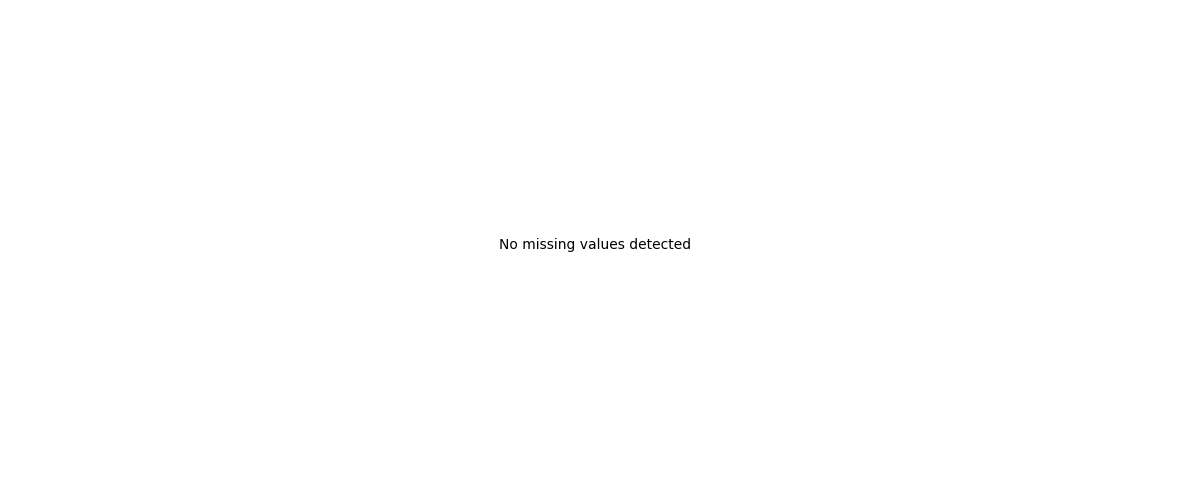

In [40]:
if "df_raw" not in globals():
    raise RuntimeError("df_raw is not defined. Run the fetch cell first.")

df_inspect = df_merged if 'df_merged' in globals() else df_raw

print('--- df.info() ---')
df_inspect.info()

na_pct = (df_inspect.isna().mean() * 100).sort_values(ascending=False)
na_pct_nonzero = na_pct[na_pct > 0]

fig, ax = plt.subplots(figsize=(12, 5))
if len(na_pct_nonzero) == 0:
    ax.text(0.5, 0.5, 'No missing values detected', ha='center', va='center')
    ax.set_axis_off()
else:
    na_pct_nonzero.plot(kind='bar', ax=ax, color='#226E9C')
    ax.set_ylabel('Missing values [%]')
    ax.set_title('Missingness by column (percentage)')
    ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()


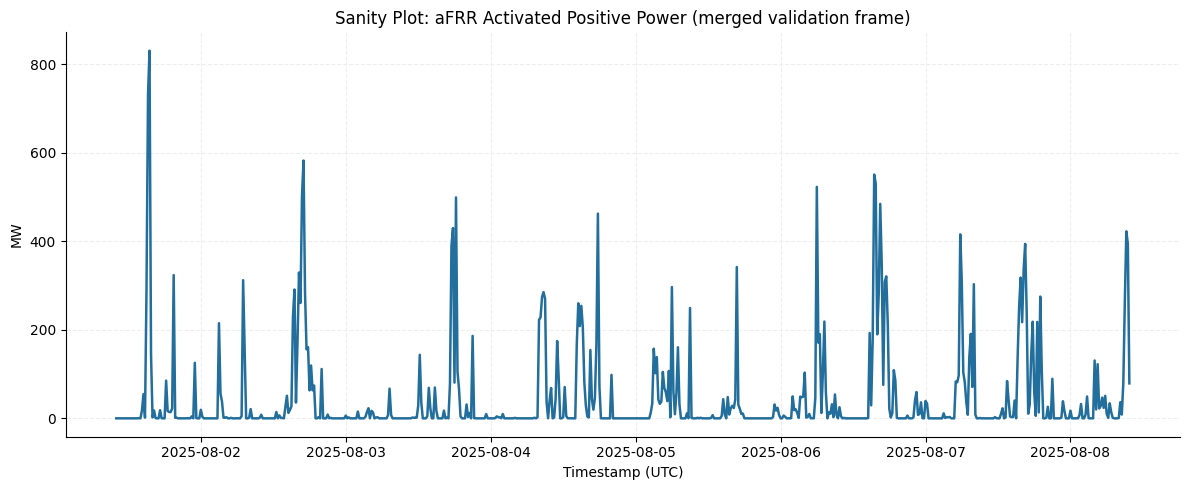

--- Timezone validation (merged) ---
First timestamp (UTC): 2025-08-01 10:00:00+00:00
Last timestamp  (UTC): 2025-08-08 09:45:00+00:00
Detected tz: UTC


In [41]:
if "df_raw" not in globals():
    raise RuntimeError("df_raw is not defined. Run the fetch cell first.")

if 'df_merged' in globals() and {'timestamp_utc','afrr_activated_mw_pos'}.issubset(df_merged.columns):
    df_work = df_merged.copy()
    plot_df = df_work[['timestamp_utc', 'afrr_activated_mw_pos']].dropna().sort_values('timestamp_utc')

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df['timestamp_utc'], plot_df['afrr_activated_mw_pos'], color='#226E9C', linewidth=1.8)
    ax.set_title('Sanity Plot: aFRR Activated Positive Power (merged validation frame)')
    ax.set_xlabel('Timestamp (UTC)')
    ax.set_ylabel('MW')
    plt.tight_layout()
    plt.show()

    idx = pd.to_datetime(df_work['timestamp_utc'], utc=True)
    print('--- Timezone validation (merged) ---')
    print('First timestamp (UTC):', idx.min())
    print('Last timestamp  (UTC):', idx.max())
    print('Detected tz:', idx.dt.tz)
else:
    df_work = df_raw.copy()
    date_col = next((c for c in df_work.columns if c.lower() == 'datum'), None)
    time_col = next((c for c in df_work.columns if c.lower() in {'von', 'time'}), None)
    if date_col and time_col:
        ts_local = pd.to_datetime(
            df_work[date_col].astype(str) + ' ' + df_work[time_col].astype(str),
            format='%d.%m.%Y %H:%M',
            errors='coerce',
        )
        ts_local = ts_local.dt.tz_localize('Europe/Berlin', ambiguous='NaT', nonexistent='shift_forward')
        ts_utc = ts_local.dt.tz_convert('UTC')
        print('--- Timezone validation (raw) ---')
        print('First timestamp (UTC):', ts_utc.min())
        print('Last timestamp  (UTC):', ts_utc.max())
        print('Detected tz:', ts_utc.dt.tz)
    else:
        print('Could not find date/time columns (Datum + von/time).')


## Export Strategy

- The validated and normalized API output is persisted in `data/raw/netztransparenz.parquet`.
- Production ingestion logic is implemented in `src/energy_trading/ingestion/fetch_netztransparenz.py`.
- The merge step aligns all sources on `timestamp_utc` to support reproducible multi-source joins in `data/processed/all_data.parquet`.
- Derived modeling datasets are generated downstream from this raw layer to preserve provenance and auditability.
